In [1]:
from typing import Callable
from pathlib import Path

from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds


ds.show.set_figures_darkbkg()

In [2]:
#BASEPATH: str = '...'
BASEPATH: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
MASK_FITS: str = "wfm_mask_NTHT_20260129_CORRECTED.fits"

UPS_X: int = 5
UPS_Y: int = 1
wfm = codedmask(f'{BASEPATH}/{MASK_FITS}', UPS_X, UPS_Y)

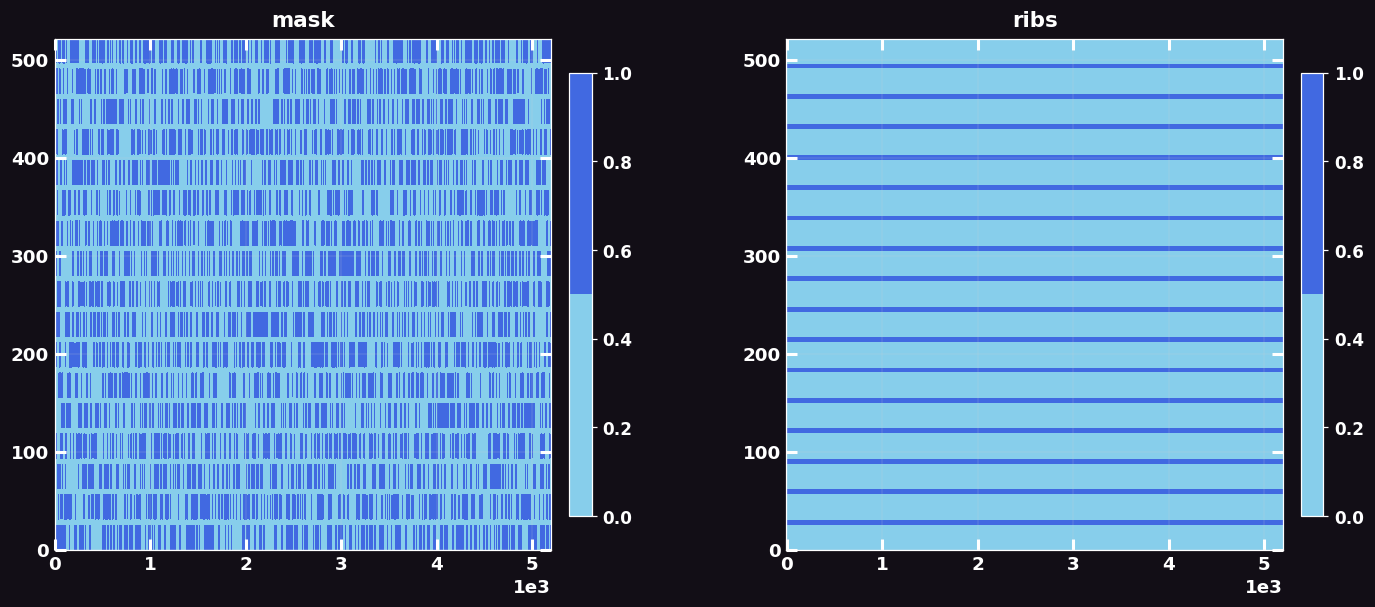

In [57]:
from matplotlib.colors import ListedColormap as lc

def get_ribs(
    camera: CodedMaskCamera,
    ely_dim: float = 13.0,
    n_ely: int = 17,
    ribsy_dim: float = 2.5,
) -> NDArray:
    """Creates a blueprint of the mask ribs."""
    px_dim_y = camera.specs.mask_deltay / camera.upscale_f.y
    n_ely_px = int(ely_dim / px_dim_y)
    n_riby_px = int(ribsy_dim / px_dim_y)
    base = np.zeros_like(camera.mask, dtype=int)
    for idx in range(n_ely):
        base[(idx + 1) * (n_ely_px + n_riby_px) - n_riby_px : (idx + 1) * (n_ely_px + n_riby_px), :] += 1
    return base



ribs: NDArray = get_ribs(wfm)

img_kwargs={
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
    'cmap': lc(["SkyBlue", "RoyalBlue"]),
}
dmaps=(
    ds.map4image(
        wfm.mask,
        title='mask',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        ribs,
        title='ribs',
        img_kwargs=img_kwargs,
    ),
    #ds.map4image(
    #    wfm.mask + ribs,
    #    title='mask + ribs',
    #    img_kwargs=img_kwargs,
    #),
)
ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)
